SCENARIO 1 – CLUSTERING USING K-MEANS

Problem Statement
Group customers/data points into clusters based on similarity using K-Means clustering.

Dataset (Kaggle – Public)
Mall Customer Segmentation Dataset
Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
(You can use any dataset with numerical features)

Target Variable: Cluster labels (no predefined labels – unsupervised learning)
Input Feature: 
• Annual Income
• Spending Score
• Age (optional)

IN-LAB TASKS 
1.	Import required Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn)
2.	Load the dataset
3.	Perform data preprocessing (handling missing values, scaling)
4.	Select relevant features
5.	Use Elbow Method to determine optimal K
6.	Apply K-Means clustering
7.	Assign cluster labels
8.	Visualize clusters
9.	Interpret cluster characteristics

Evaluation Metrics
• Inertia (Within-cluster sum of squares)
• Silhouette Score

Analysis Tasks
• Observe how different K values affect clustering
• Analyze compactness and separation of clusters
• Identify customer segments (e.g., high income–high spending)
• Study sensitivity to initialization


In [1]:
# Step 1: Import required Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Suppress joblib/loky warnings
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

In [3]:
# Step 2: Load the dataset
df = pd.read_csv(r"D:\SEM4\ml\lab\dataset\7 th\Mall_Customers.csv")

# Display first few rows
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
No

In [4]:
print("\n--- DATA PREPROCESSING ---")
print(f"Missing values: {df.isnull().sum().sum()}")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(f"Features: Annual Income, Spending Score")
print(f"Shape: {X.shape}")


--- DATA PREPROCESSING ---
Missing values: 0
Features: Annual Income, Spending Score
Shape: (200, 2)


In [5]:
print("\n--- FEATURE SCALING ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled features (StandardScaler)")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")


--- FEATURE SCALING ---
Scaled features (StandardScaler)
Mean: [-2.13162821e-16 -1.46549439e-16]
Std: [1. 1.]


In [6]:
print("\n--- ELBOW METHOD ---")
K_range = range(2, 11)
inertias, silhouette_scores = [], []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

optimal_k = K_range[np.argmax(silhouette_scores)]

print(f"\n{'K':<5} {'Inertia':<15} {'Silhouette':<15}")
print("-"*35)
for i, k in enumerate(K_range):
    marker = "*" if k == optimal_k else ""
    print(f"{k:<5} {inertias[i]:<15.2f} {silhouette_scores[i]:<15.4f} {marker}")
print(f"\nOptimal K: {optimal_k}")


--- ELBOW METHOD ---

K     Inertia         Silhouette     
-----------------------------------
2     269.69          0.3213          
3     157.70          0.4666          
4     108.92          0.4939          
5     65.57           0.5547          *
6     55.06           0.5399          
7     44.86           0.5281          
8     37.23           0.4552          
9     32.39           0.4571          
10    29.98           0.4432          

Optimal K: 5


In [7]:
print("\n--- K-MEANS CLUSTERING ---")
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(f"K: {optimal_k}")
print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")


--- K-MEANS CLUSTERING ---
K: 5
Inertia: 65.57
Silhouette Score: 0.5547


In [8]:
print("\n--- CLUSTER ASSIGNMENT ---")
df['Cluster'] = cluster_labels
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head(10))
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())


--- CLUSTER ASSIGNMENT ---
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        4
1           2                  15                      81        2
2           3                  16                       6        4
3           4                  16                      77        2
4           5                  17                      40        4
5           6                  17                      76        2
6           7                  18                       6        4
7           8                  18                      94        2
8           9                  19                       3        4
9          10                  19                      72        2

Cluster Distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64



--- VISUALIZATIONS ---


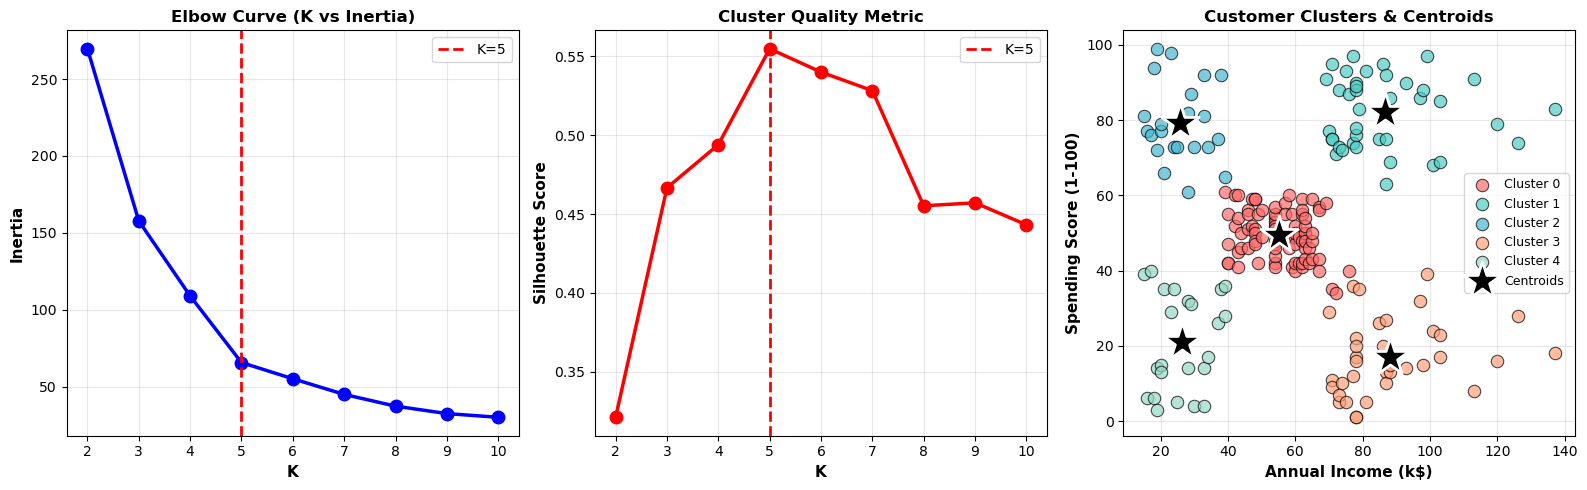

✓ Visualizations completed


In [9]:
print("\n--- VISUALIZATIONS ---")

fig = plt.figure(figsize=(16, 5))

# Elbow Curve
ax1 = plt.subplot(1, 3, 1)
ax1.plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=9)
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'K={optimal_k}')
ax1.set_xlabel('K', fontweight='bold', fontsize=11)
ax1.set_ylabel('Inertia', fontweight='bold', fontsize=11)
ax1.set_title('Elbow Curve (K vs Inertia)', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Silhouette Score
ax2 = plt.subplot(1, 3, 2)
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2.5, markersize=9)
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'K={optimal_k}')
ax2.set_xlabel('K', fontweight='bold', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontweight='bold', fontsize=11)
ax2.set_title('Cluster Quality Metric', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Scatter Plot with Centroids
ax3 = plt.subplot(1, 3, 3)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    ax3.scatter(df[mask]['Annual Income (k$)'], 
                df[mask]['Spending Score (1-100)'],
                c=colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black', linewidth=0.8)

centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
ax3.scatter(centers_original[:, 0], centers_original[:, 1],
            c='black', marker='*', s=800, edgecolors='white', linewidth=2, label='Centroids', zorder=5)
ax3.set_xlabel('Annual Income (k$)', fontweight='bold', fontsize=11)
ax3.set_ylabel('Spending Score (1-100)', fontweight='bold', fontsize=11)
ax3.set_title('Customer Clusters & Centroids', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizations completed")

In [10]:
print("\n--- CLUSTER PROFILES ---")

for cluster in range(optimal_k):
    data = df[df['Cluster'] == cluster]
    income = data['Annual Income (k$)'].mean()
    spending = data['Spending Score (1-100)'].mean()
    
    if income > 60 and spending > 60:
        profile = "Premium Customers (High Income, High Spending)"
    elif income > 60 and spending < 40:
        profile = "Savers (High Income, Low Spending)"
    elif income < 40 and spending > 60:
        profile = "Spenders (Low Income, High Spending)"
    elif income < 40 and spending < 40:
        profile = "Budget-conscious (Low Income, Low Spending)"
    else:
        profile = "Standard Customers (Medium Income, Medium Spending)"
    
    print(f"\nCluster {cluster}: {len(data)} customers")
    print(f"Income: ${income:.1f}k | Spending: {spending:.1f}/100 | {profile}")


--- CLUSTER PROFILES ---

Cluster 0: 81 customers
Income: $55.3k | Spending: 49.5/100 | Standard Customers (Medium Income, Medium Spending)

Cluster 1: 39 customers
Income: $86.5k | Spending: 82.1/100 | Premium Customers (High Income, High Spending)

Cluster 2: 22 customers
Income: $25.7k | Spending: 79.4/100 | Spenders (Low Income, High Spending)

Cluster 3: 35 customers
Income: $88.2k | Spending: 17.1/100 | Savers (High Income, Low Spending)

Cluster 4: 23 customers
Income: $26.3k | Spending: 20.9/100 | Budget-conscious (Low Income, Low Spending)


SCENARIO 2 – CLUSTERING USING GMM

Problem Statement
Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

Dataset (Same / Alternative Dataset)
Same dataset (or any numerical dataset)

Target Variable: Cluster probabilities and labels
Input Features
• Annual Income
• Spending Score
• Age (optional)

IN-LAB TASKS 
1.	Load dataset
2.	Perform preprocessing and scaling
3.	Apply Gaussian Mixture Model (GMM)
4.	Choose number of components (clusters)
5.	Fit model using Expectation-Maximization (EM)
6.	Predict cluster probabilities
7.	Assign clusters based on highest probability
8.	Compare with K-Means clustering

Evaluation Metrics
• Log-Likelihood
• AIC (Akaike Information Criterion)
• BIC (Bayesian Information Criterion)
• Silhouette Score

Analysis Tasks
• Compare soft vs hard clustering
• Analyze overlapping clusters
• Observe cluster shapes (elliptical vs spherical)
• Compare flexibility with K-Means

Visualization
• Cluster probability distribution
• GMM contour plots
• Comparison plot (K-Means vs GMM)


In [11]:
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde

print("\n" + "="*40)
print("SCENARIO 2: GAUSSIAN MIXTURE MODELS")
print("="*40)


SCENARIO 2: GAUSSIAN MIXTURE MODELS


In [12]:
print("\n--- OPTIMAL COMPONENTS ---")
n_components_range = range(2, 11)
bic_scores = []
aic_scores = []
log_likelihoods = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    log_likelihoods.append(gmm.score(X_scaled))

optimal_components = n_components_range[np.argmin(bic_scores)]

print(f"\n{'Components':<12} {'BIC':<15} {'AIC':<15}")
print("-"*42)
for i, n in enumerate(n_components_range):
    marker = "*" if n == optimal_components else ""
    print(f"{n:<12} {bic_scores[i]:<15.2f} {aic_scores[i]:<15.2f} {marker}")
print(f"\nOptimal Components: {optimal_components}")


--- OPTIMAL COMPONENTS ---

Components   BIC             AIC            
------------------------------------------
2            1148.47         1112.19         
3            1116.50         1060.43         
4            1079.49         1003.63         
5            1058.65         963.00          *
6            1071.57         956.13          
7            1085.59         950.36          
8            1082.48         927.46          
9            1089.77         914.96          
10           1110.78         916.18          

Optimal Components: 5


In [13]:
print("\n--- FIT GMM ---")
gmm_final = GaussianMixture(n_components=optimal_components, random_state=42, n_init=10)
gmm_final.fit(X_scaled)

print(f"Components: {optimal_components}")
print(f"Log-Likelihood: {gmm_final.score(X_scaled):.4f}")
print(f"BIC: {gmm_final.bic(X_scaled):.2f}")
print(f"AIC: {gmm_final.aic(X_scaled):.2f}")


--- FIT GMM ---
Components: 5
Log-Likelihood: -2.2625
BIC: 1058.65
AIC: 963.00


In [14]:
print("\n--- CLUSTER ASSIGNMENT ---")
cluster_probs = gmm_final.predict_proba(X_scaled)
gmm_labels = gmm_final.predict(X_scaled)

df['GMM_Cluster'] = gmm_labels
df['GMM_Probability'] = cluster_probs.max(axis=1)

print("GMM Assignments (first 10):")
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'GMM_Cluster', 'GMM_Probability']].head(10))
print(f"\nCluster Distribution:")
print(df['GMM_Cluster'].value_counts().sort_index())


--- CLUSTER ASSIGNMENT ---
GMM Assignments (first 10):
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0           1                  15                      39        4   
1           2                  15                      81        2   
2           3                  16                       6        4   
3           4                  16                      77        2   
4           5                  17                      40        4   
5           6                  17                      76        2   
6           7                  18                       6        4   
7           8                  18                      94        2   
8           9                  19                       3        4   
9          10                  19                      72        2   

   GMM_Cluster  GMM_Probability  
0            4         0.999032  
1            2         0.999790  
2            4         0.999814  
3            2         0.999694  
4  


--- VISUALIZATIONS ---


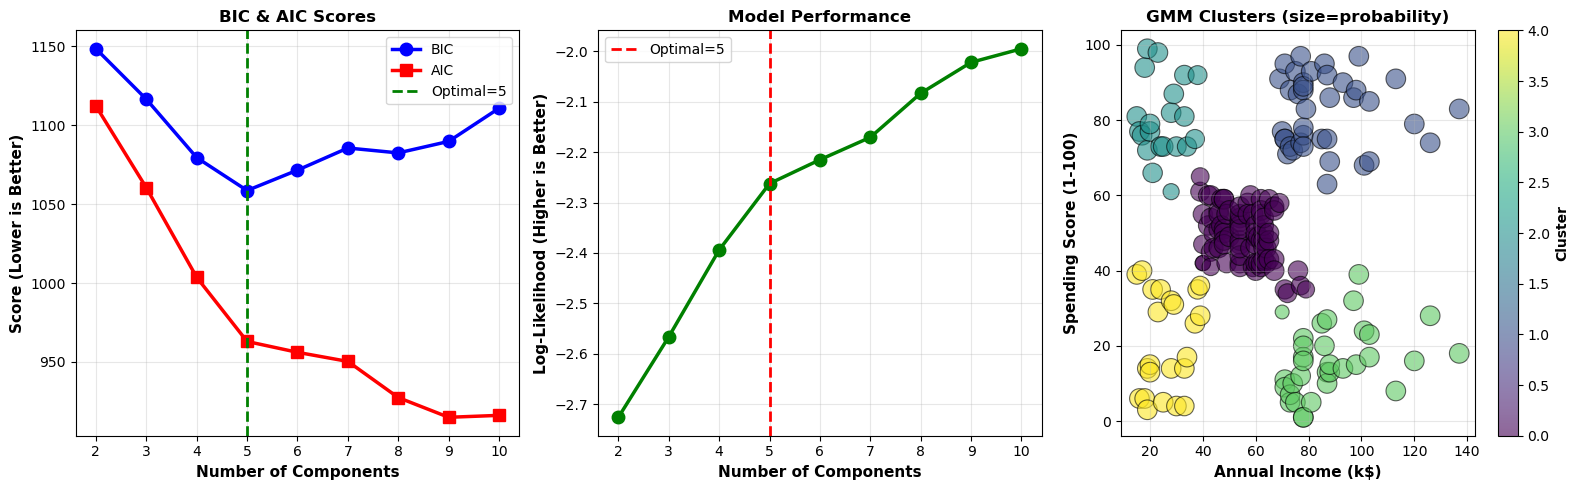

✓ GMM visualizations completed


In [15]:
print("\n--- VISUALIZATIONS ---")

fig = plt.figure(figsize=(16, 5))

# BIC & AIC Comparison
ax1 = plt.subplot(1, 3, 1)
ax1.plot(n_components_range, bic_scores, 'bo-', label='BIC', linewidth=2.5, markersize=9)
ax1.plot(n_components_range, aic_scores, 'rs-', label='AIC', linewidth=2.5, markersize=9)
ax1.axvline(x=optimal_components, color='green', linestyle='--', linewidth=2, label=f'Optimal={optimal_components}')
ax1.set_xlabel('Number of Components', fontweight='bold', fontsize=11)
ax1.set_ylabel('Score (Lower is Better)', fontweight='bold', fontsize=11)
ax1.set_title('BIC & AIC Scores', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Log-Likelihood
ax2 = plt.subplot(1, 3, 2)
ax2.plot(n_components_range, log_likelihoods, 'go-', linewidth=2.5, markersize=9)
ax2.axvline(x=optimal_components, color='red', linestyle='--', linewidth=2, label=f'Optimal={optimal_components}')
ax2.set_xlabel('Number of Components', fontweight='bold', fontsize=11)
ax2.set_ylabel('Log-Likelihood (Higher is Better)', fontweight='bold', fontsize=11)
ax2.set_title('Model Performance', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# GMM Clusters with Probability
ax3 = plt.subplot(1, 3, 3)
scatter = ax3.scatter(df['Annual Income (k$)'], 
                      df['Spending Score (1-100)'],
                      c=df['GMM_Cluster'], 
                      s=df['GMM_Probability']*200,  # Size by probability
                      cmap='viridis', 
                      alpha=0.6, 
                      edgecolors='black', 
                      linewidth=0.8)
ax3.set_xlabel('Annual Income (k$)', fontweight='bold', fontsize=11)
ax3.set_ylabel('Spending Score (1-100)', fontweight='bold', fontsize=11)
ax3.set_title('GMM Clusters (size=probability)', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ GMM visualizations completed")


--- K-MEANS vs GMM ---


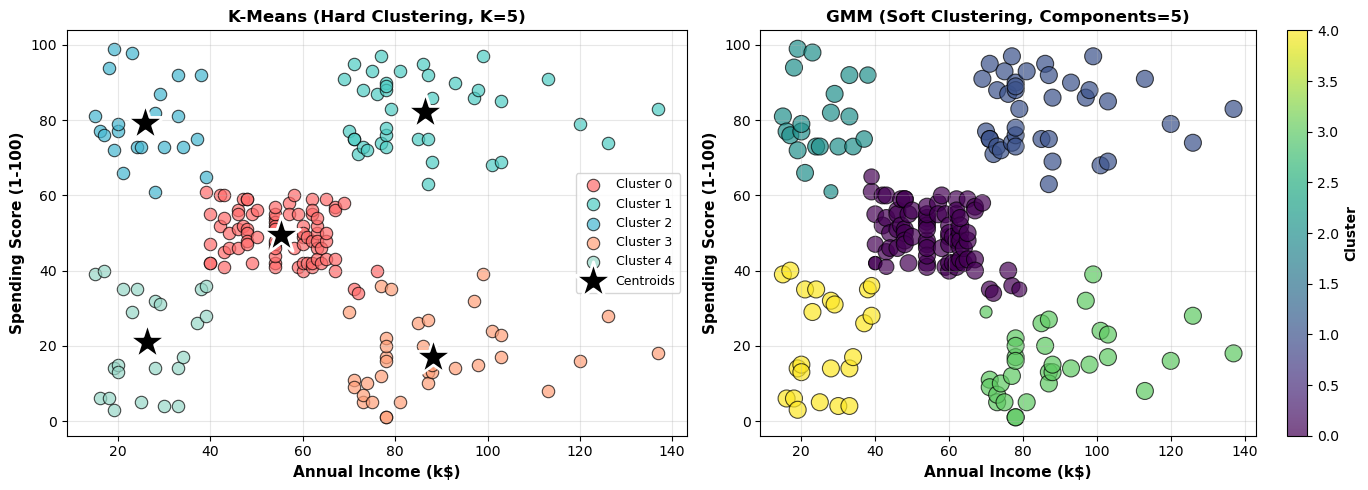

✓ Comparison visualization completed


In [16]:
print("\n--- K-MEANS vs GMM ---")

# Create comparison visualization
fig = plt.figure(figsize=(14, 5))

# K-Means Clustering
ax1 = plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    ax1.scatter(df[mask]['Annual Income (k$)'], 
                df[mask]['Spending Score (1-100)'],
                c=colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black', linewidth=0.8)

centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
ax1.scatter(centers_original[:, 0], centers_original[:, 1],
            c='black', marker='*', s=800, edgecolors='white', linewidth=2, label='Centroids', zorder=5)
ax1.set_xlabel('Annual Income (k$)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Spending Score (1-100)', fontweight='bold', fontsize=11)
ax1.set_title(f'K-Means (Hard Clustering, K={optimal_k})', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# GMM Clustering
ax2 = plt.subplot(1, 2, 2)
scatter = ax2.scatter(df['Annual Income (k$)'], 
                      df['Spending Score (1-100)'],
                      c=df['GMM_Cluster'], 
                      s=df['GMM_Probability']*150, 
                      cmap='viridis', 
                      alpha=0.7, 
                      edgecolors='black', 
                      linewidth=0.8)
ax2.set_xlabel('Annual Income (k$)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Spending Score (1-100)', fontweight='bold', fontsize=11)
ax2.set_title(f'GMM (Soft Clustering, Components={optimal_components})', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Comparison visualization completed")

In [17]:
print("\n--- CLUSTER PROFILES ---")

for cluster in range(optimal_components):
    data = df[df['GMM_Cluster'] == cluster]
    income = data['Annual Income (k$)'].mean()
    spending = data['Spending Score (1-100)'].mean()
    avg_prob = data['GMM_Probability'].mean()
    
    if income > 60 and spending > 60:
        profile = "Premium Customers"
    elif income > 60 and spending < 40:
        profile = "Savers"
    elif income < 40 and spending > 60:
        profile = "Spenders"
    elif income < 40 and spending < 40:
        profile = "Budget-conscious"
    else:
        profile = "Standard Customers"
    
    print(f"\nGMM Cluster {cluster}: {len(data):3d} customers")
    print(f"  Income: ${income:6.1f}k | Spending: {spending:5.1f}/100")
    print(f"  Avg Probability: {avg_prob:.4f} | Profile: {profile}")


--- CLUSTER PROFILES ---

GMM Cluster 0:  84 customers
  Income: $  55.6k | Spending:  49.4/100
  Avg Probability: 0.9732 | Profile: Standard Customers

GMM Cluster 1:  39 customers
  Income: $  86.5k | Spending:  82.1/100
  Avg Probability: 1.0000 | Profile: Premium Customers

GMM Cluster 2:  21 customers
  Income: $  25.1k | Spending:  80.0/100
  Avg Probability: 0.9735 | Profile: Spenders

GMM Cluster 3:  33 customers
  Income: $  88.8k | Spending:  16.0/100
  Avg Probability: 0.9840 | Profile: Savers

GMM Cluster 4:  23 customers
  Income: $  26.3k | Spending:  20.9/100
  Avg Probability: 0.9943 | Profile: Budget-conscious


In [18]:
print("\n--- COMPARISON ---")
from sklearn.metrics import silhouette_score
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"\n{'Metric':<20} {'K-Means':<20} {'GMM':<20}")
print("-"*60)
print(f"{'Clusters':<20} {optimal_k:<20} {optimal_components:<20}")
print(f"{'Inertia/BIC':<20} {kmeans_final.inertia_:<20.2f} {gmm_final.bic(X_scaled):<20.2f}")
print(f"{'Silhouette':<20} {kmeans_silhouette:<20.4f} {gmm_silhouette:<20.4f}")
print(f"{'Log-Likelihood':<20} {'N/A':<20} {gmm_final.score(X_scaled):<20.4f}")

agreement = np.sum(df['Cluster'] == df['GMM_Cluster']) / len(df)
print(f"\nLabel Agreement: {agreement*100:.1f}%")
print("\nKey Differences:")
print("K-Means: Hard clustering, spherical clusters, deterministic")
print("GMM: Soft clustering, elliptical clusters, probabilistic")


--- COMPARISON ---

Metric               K-Means              GMM                 
------------------------------------------------------------
Clusters             5                    5                   
Inertia/BIC          65.57                1058.65             
Silhouette           0.5547               0.5537              
Log-Likelihood       N/A                  -2.2625             

Label Agreement: 98.5%

Key Differences:
K-Means: Hard clustering, spherical clusters, deterministic
GMM: Soft clustering, elliptical clusters, probabilistic
